<div style="font-family: 'Times New Roman', serif; text-align: center; padding: 20px 0;">

<hr style="border: none; border-top: 1px solid #444;">

<p style="font-size: 13px; letter-spacing: 3px; color: #666; margin: 15px 0 8px 0;">
PATCH COMPOSITION
</p>

<p style="font-size: 32px; font-weight: bold; margin: 0 0 15px 0;">
Patch - Solar Orbiter
</p>

<hr style="border: none; border-top: 1px solid #444; width: 80%;">

</div>

In [1]:
""" Import Modules """
import numpy             as np
import pandas            as pd
import speasy            as spz
import matplotlib.pyplot as plt

from matplotlib        import rcParams
from scipy.interpolate import interp1d
from scipy             import interpolate, stats
from datetime          import datetime, timedelta

from f_patch import average, load_data_solo

In [2]:
""" Plot Config """
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 13
rcParams['axes.titlesize'] = 18
rcParams['axes.labelsize'] = 15
rcParams['xtick.labelsize'] = 13
rcParams['ytick.labelsize'] = 13
rcParams['legend.fontsize'] = 14
rcParams['figure.titlesize'] = 18

rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['grid.linestyle'] = '--'
rcParams['grid.linewidth'] = 0.5

In [128]:
""" Time Config """
start_SOLO = datetime(2022, 10, 21) 
stop_SOLO  = datetime(2022, 10, 29)

In [130]:
""" Get Data """ 
data_solo = load_data_solo(start_SOLO, stop_SOLO)
data_solo

,car_lon,car_lat,r_sun,Np,Vp_r,Vp_t,Vp_n,Tp,Br,Bt,Bn
2022-10-21 00:00:00.440000000,167.790199,4.550172,0.345848,18.552172,641.013245,3.032162,96.387466,41.296894,30.260260,-4.039718,-17.580931
2022-10-21 00:00:16.440000000,167.788589,4.550288,0.345850,19.574339,646.178833,-18.947115,99.306458,45.393951,29.259060,0.035032,-18.121714
2022-10-21 00:00:20.440000000,167.788186,4.550318,0.345851,19.720284,645.812927,-21.168915,97.373932,46.164688,29.210524,1.015725,-18.475485
2022-10-21 00:00:24.440999936,167.787783,4.550347,0.345851,20.625912,637.678406,-21.554276,81.815941,48.269348,30.843674,0.428082,-14.510586
2022-10-21 00:00:28.440999936,167.787381,4.550376,0.345852,20.124710,638.935913,-44.220619,85.049751,46.910480,30.432425,3.954996,-14.908231
...,...,...,...,...,...,...,...,...,...,...,...
2022-10-28 17:43:33.617999872,91.425604,7.419523,0.446034,13.654726,321.248352,17.618345,-49.796703,3.712230,20.238447,-9.771931,16.448273
2022-10-28 17:43:37.617999872,91.425102,7.419532,0.446035,14.330170,326.792938,16.141476,-59.553555,4.021622,19.264408,-9.550236,17.630560
2022-10-28 17:43:41.617999872,91.424600,7.419540,0.446035,17.082949,335.083923,33.684715,-51.872063,3.916489,18.390083,-12.639926,16.603886
2022-10-28 17:43:45.617999872,91.424098,7.419548,0.446036,14.005121,328.053284,17.752924,-59.084644,3.977711,19.156546,-9.794101,17.625908


In [131]:
""" Derived Parameters """
# alpha_abundance_solo = data_solo['Na'] / (data_solo['Na'] + data_solo['Np'])*100

' Derived Parameters '

Text(1.08, 0.5, '— $r$ $[AU]$')

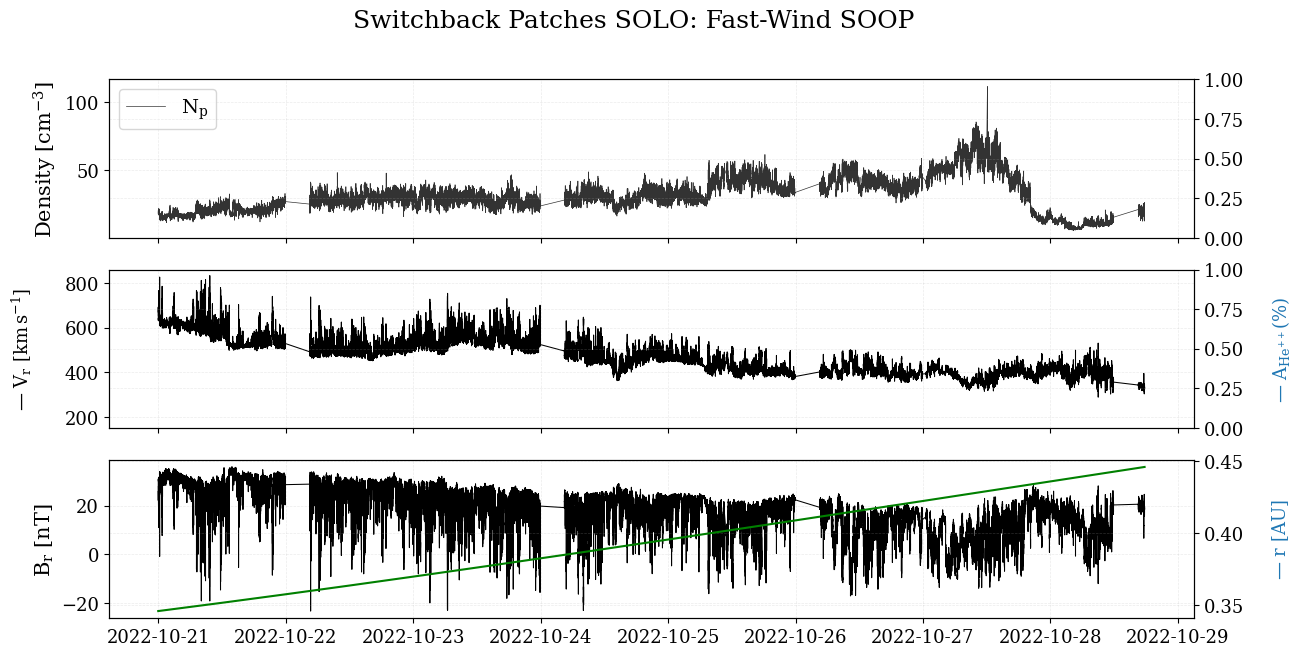

In [132]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(14,7))
fig.suptitle("Switchback Patches SOLO: Fast-Wind SOOP")

plt.rcParams["mathtext.default"] = "regular"

time_index = data_solo.index

ax1b = ax1.twinx()
ax1.plot(time_index, data_solo['Np'], label='$N_p$', color='black', linewidth='0.5', alpha=0.8)
# ax1b.plot(Na_PSP.index, Na_PSP.iloc[:,0], label='$N_a$', color='tab:red', linewidth='0.5', alpha=0.8)
ax1.legend(loc='upper left')
# ax1b.legend(loc='upper right')
ax1.set_ylabel('Density $[cm^{-3}]$')

ax2b = ax2.twinx()
ax2.plot(time_index, data_solo['Vp_r'], label='$V_p$', color='black', linewidth='0.75')
# ax2b.plot(time_index,alpha_abundance_PSP_average,label=r'$\alpha _{\%}$',color='tab:blue',linewidth=0.75,alpha=0.8)
# ax2b.set_yscale('log')
ax2.annotate(
    r'— $V_r$ $[km\,s^{-1}]$',
    xy=(-0.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='black')
ax2.set_ylim(150, None)

ax2b.annotate(
    r'— $A_{He^{++}} (\%)$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')

ax3b = ax3.twinx()
ax3.plot(time_index, data_solo['Br'], color ='black', linewidth='0.75')
ax3b.plot(time_index, data_solo['r_sun'], color='green')
ax3.set_ylabel('$B_r$ $[nT]$')
ax3b.annotate(
    r'— $r$ $[AU]$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')
# ax3b.set_ylim(None,0.2)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Angular Displacement
</p>

</div>

In [137]:
""" Ephemeris Data """
phi, theta, solo_r_sun = data_solo['car_lon'], data_solo['car_lat'], data_solo['r_sun']

In [139]:
phi

2022-10-21 00:00:00.440000000    167.790199
2022-10-21 00:00:16.440000000    167.788589
2022-10-21 00:00:20.440000000    167.788186
2022-10-21 00:00:24.440999936    167.787783
2022-10-21 00:00:28.440999936    167.787381
                                    ...    
2022-10-28 17:43:33.617999872     91.425604
2022-10-28 17:43:37.617999872     91.425102
2022-10-28 17:43:41.617999872     91.424600
2022-10-28 17:43:45.617999872     91.424098
2022-10-28 17:43:49.617999872     91.423596
Name: car_lon, Length: 148352, dtype: float64

In [142]:
t_coord = time_index

phi_rad   = phi * np.pi/180
theta_rad = theta * np.pi/180

phi_rad_new   = phi_rad#['lon iau_sun']
theta_rad_new = theta_rad#['lat iau_sun']

t_coord_float = t_coord.astype(np.int64) / 1e9
df_time_float = data_solo['Vp_r'].index.astype(np.int64) / 1e9

interp_theta = interp1d(t_coord_float, theta_rad_new, kind='linear', bounds_error=False, fill_value="extrapolate")
interp_phi   = interp1d(t_coord_float, phi_rad_new,   kind='linear', bounds_error=False, fill_value="extrapolate")

theta_z = interp_theta(df_time_float)
phi_z   = interp_phi(df_time_float)

dtheta = np.diff(theta_z)
dphi   = np.diff(phi_z)

ds_solo    = np.sqrt(dtheta**2 + (np.cos(theta_z[:-1]) * dphi)**2)
s_solo     = np.concatenate([[0], np.cumsum(ds_solo)])
s_solo_deg = np.degrees(s_solo)

(150.0, 861.4400146484375)

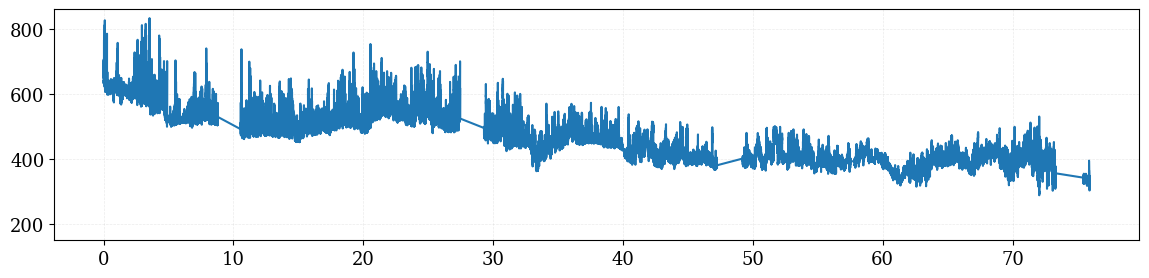

In [144]:
plt.figure(figsize=(14,3))
plt.plot(s_solo_deg, data_solo['Vp_r'])
plt.ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Fourier Analysis
</p>

</div>

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Normalised Deflection

In [198]:
""" Compute Normalised Deflection """

' Compute Normalised Deflection '

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Velocity

In [148]:
data_solo['Vp_r'] = data_solo['Vp_r'].fillna(data_solo['Vp_r'].mean())

# --- Regular sampling ---
s_solo_new = np.linspace(0, max(s_solo_deg), int(max(s_solo_deg)/min(np.diff(s_solo_deg))))

v_r_interp = interp1d(s_solo_deg, data_solo['Vp_r'], kind='linear', bounds_error=False, fill_value="extrapolate")
v_r_new = v_r_interp(s_solo_new)

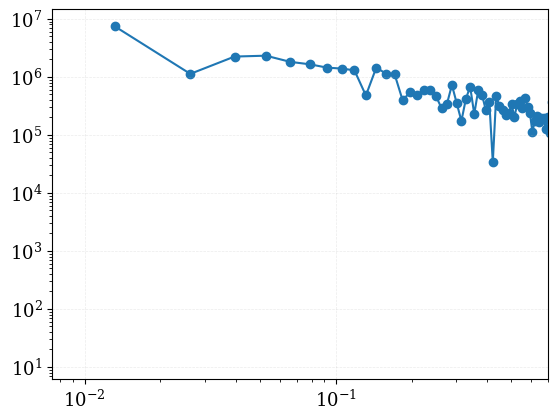

In [150]:
# --- velocity
ds_vr = np.mean(np.diff(s_solo_new))

fft_vr  = np.fft.rfft(v_r_new)
freq_vr = np.fft.rfftfreq(len(v_r_new), d=ds_vr)

plt.loglog(freq_vr[1:], np.abs(fft_vr[1:]))
plt.scatter(freq_vr[1:], np.abs(fft_vr[1:]))
# plt.axvline(1e-1, color="orange")
plt.xlim(None, 7e-1)
plt.show()

In [152]:
fft_vr[14:] = 0.0

(150.0, 854.9555339649193)

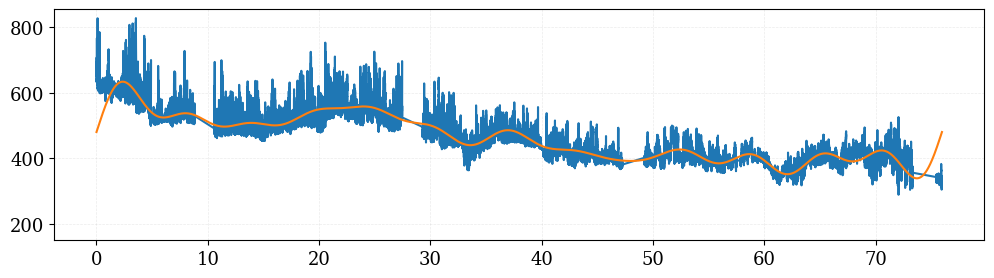

In [156]:
filter_data_vr = np.fft.irfft(fft_vr)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_solo_new, v_r_new)
ax.plot(s_solo_new, filter_data_vr)
ax.set_ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Alpha Abundance

In [159]:
from f_patch import _read_velocirap_file, resample_dataframe

In [161]:
data = _read_velocirap_file(start_SOLO, stop_SOLO)

In [162]:
data

,Np,Na,Vp_r,Vp_t,Vp_n,Va_r,Va_t,Va_n
time,,,,,,,,
2022-10-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-21 00:00:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-21 00:00:02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-21 00:00:03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-21 00:00:04,20.504432,0.337321,638.815803,6.464258,106.80749,734.952263,-16.318338,34.925492
...,...,...,...,...,...,...,...,...
2022-10-28 23:59:55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-28 23:59:56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-28 23:59:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
data_res = resample_dataframe(data, data_solo.index)
data_res

,Np,Na,Vp_r,Vp_t,Vp_n,Va_r,Va_t,Va_n
2022-10-21 00:00:00.440000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-21 00:00:16.440000000,21.197919,0.430662,641.858496,-15.134971,109.864266,703.467894,-15.127292,55.483413
2022-10-21 00:00:20.440000000,20.873080,0.852455,640.865753,-17.841012,108.198072,596.180703,-9.038983,69.808518
2022-10-21 00:00:24.440999936,22.115742,0.735543,632.983764,-18.398414,91.233949,609.293815,-7.650324,59.151617
2022-10-21 00:00:28.440999936,21.303213,1.091480,632.491371,-40.645729,93.832123,575.626023,-22.063480,64.382659
...,...,...,...,...,...,...,...,...
2022-10-28 17:43:33.617999872,14.443799,0.380267,321.702629,17.309448,-48.174698,316.883217,16.626410,-41.161663
2022-10-28 17:43:37.617999872,15.124697,0.420174,327.492775,16.148323,-57.706421,330.148441,18.618551,-47.109364
2022-10-28 17:43:41.617999872,18.061930,0.389915,334.969101,33.214020,-50.830435,335.691865,31.826091,-46.700960
2022-10-28 17:43:45.617999872,14.754451,0.435186,328.232148,17.004521,-57.590596,327.917329,15.151777,-47.812124


In [167]:
alpha_abundance_SOLO = (data_res['Na'] / (data_res['Na'] + data_res['Np'])) * 100
alpha_percent = pd.DataFrame(alpha_abundance_SOLO)
alpha_percent.columns = ["a_percent"]

In [169]:
alpha_percent.loc[np.isnan(alpha_percent['a_percent']), "a_percent"] = np.mean(alpha_percent['a_percent'])

# --- Regular sampling ---
a_percent_interp = interp1d(s_solo_deg, alpha_percent['a_percent'], kind='linear', bounds_error=False, fill_value="extrapolate")
a_percent_new = a_percent_interp(s_solo_new)

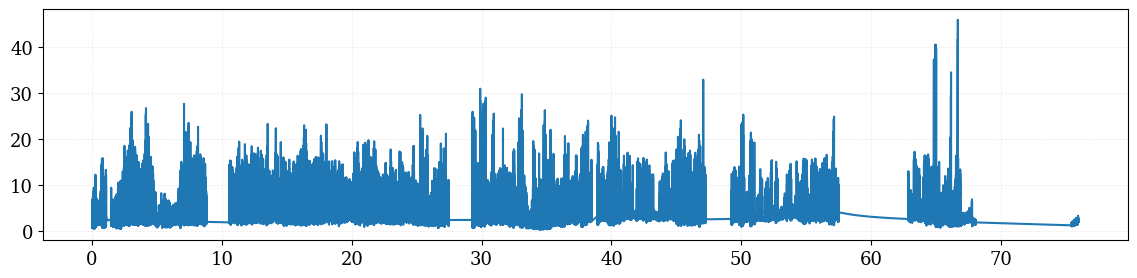

In [171]:
plt.figure(figsize=(14, 3))
plt.plot(s_solo_new, a_percent_new)

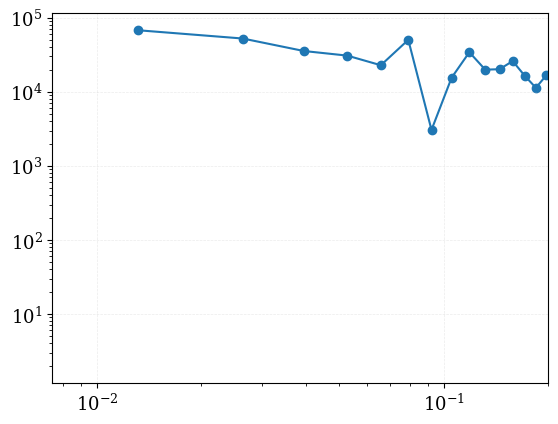

In [173]:
# --- alpha abundance
ds_a_percent = np.mean(np.diff(s_solo_new))

fft_a_percent  = np.fft.rfft(a_percent_new)
freq_a_percent = np.fft.rfftfreq(len(a_percent_new), d=ds_a_percent)

plt.loglog(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
plt.scatter(freq_a_percent[1:], np.abs(fft_a_percent[1:]))
# plt.axvline(1e-1, color="orange")
plt.xlim(None, 2e-1)
plt.show()

In [175]:
fft_a_percent[14:] = 0.0

In [177]:
filter_data_a_percent

array([2.45537579, 2.4550555 , 2.45473507, ..., 2.45633581, 2.45601594,
       2.45569594], shape=(87648,))

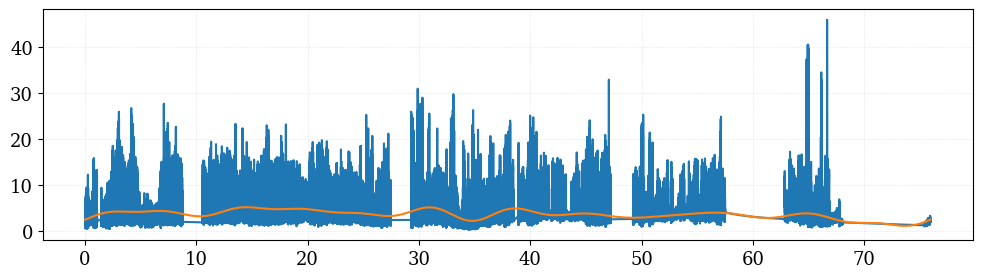

In [181]:
filter_data_a_percent = np.fft.irfft(fft_a_percent)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_solo_new, a_percent_new)
ax.plot(s_solo_new, filter_data_a_percent)
#ax.set_ylim(150, None)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Correlation
</p>

</div>

In [184]:
r_a_vr, p_a_vr = stats.pearsonr(filter_data_vr, filter_data_a_percent)
r_a_vr

np.float64(0.563381198080167)